In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import seaborn as sns
import plotly.graph_objects as go

In [ ]:
# Combine all 5 CSVs by summing values for matching country/year, excluding domestic players in each league

# List your CSV file paths and the domestic country row to exclude for each
csv_info = [
    ("Serie_A_Num_Of_Players.csv", "it Italy"),
    ("countries_Num_Of_Players.csv", "fr France"),
    ("PL_Num_Of_Players.csv", "eng England"),
    ("La_Liga_Num_Of_Players.csv", "es Spain"),
    ("Bundesliga_Num_Of_Players.csv", "de Germany"),
]

dfs = []
for fname, domestic_row in csv_info:
    df = pd.read_csv(fname, index_col=0)
    # Remove the domestic row if it exists
    if domestic_row in df.index:
        df = df.drop(index=domestic_row)
    dfs.append(df)

# Align all DataFrames to the union of all indices and columns, filling missing with 0
all_countries = sorted(set().union(*[df.index for df in dfs]))
all_years = sorted(set().union(*[df.columns for df in dfs]))

dfs_aligned = [df.reindex(index=all_countries, columns=all_years, fill_value=0) for df in dfs]

# Sum all DataFrames elementwise
combined = reduce(lambda a, b: a.add(b, fill_value=0), dfs_aligned)

# Save or display the result
combined = combined.astype(int)
combined.to_csv("Countries_Num_Of_Players.csv")
combined.head()

,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Serbia and Montenegro,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ad Andorra,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,1,1
ae United Arab Emirates,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
af Afghanistan,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
ag Antigua and Barbuda,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [5]:
# Sort the combined dataset by the total sum of each row (descending)

combined_sorted = combined.copy()
combined_sorted["Total"] = combined_sorted.sum(axis=1)
combined_sorted = combined_sorted.sort_values("Total", ascending=False)
combined_sorted = combined_sorted.drop(columns="Total")
combined_sorted.to_csv("Countries_Num_Of_Players_Sorted.csv")

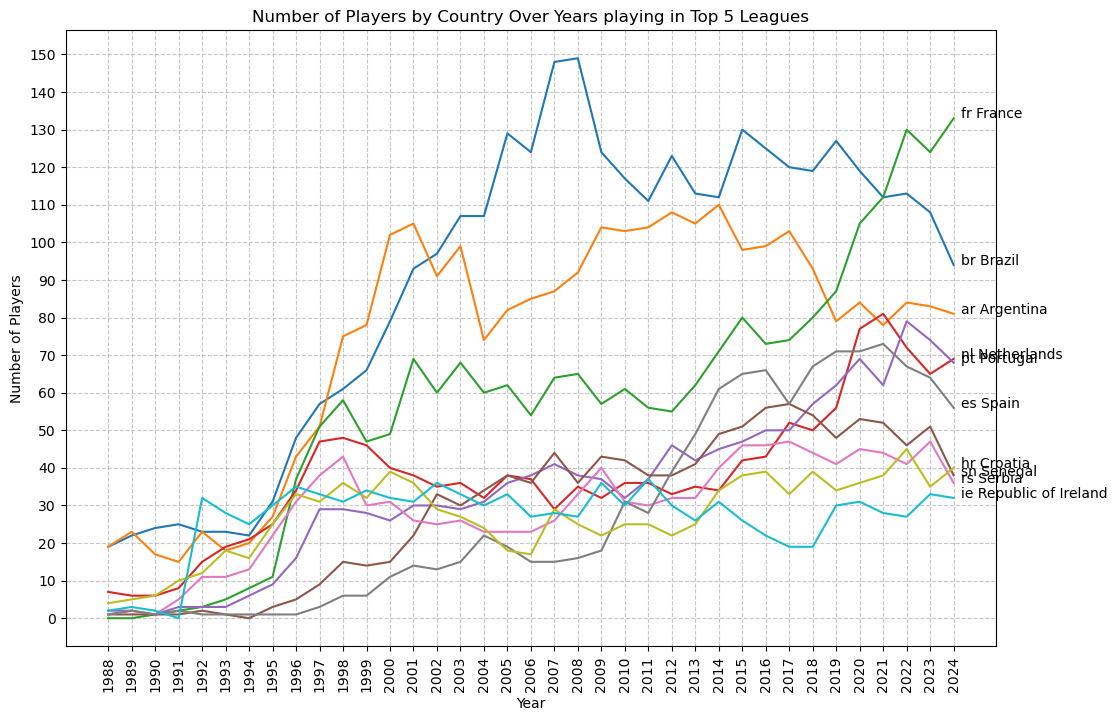

In [11]:
countries_num = pd.read_csv("Countries_Num_Of_Players_Sorted.csv", index_col=0)

# Select the top 10 countries 
countries_num_top_10 = countries_num.iloc[0:10]

# Plot each country's data
plt.figure(figsize=(12, 8))
for index, row in countries_num_top_10.iterrows():
    plt.plot(row.index, row.values, label=index)
    plt.annotate(index, xy=(row.index[-1], row.values[-1]), xytext=(5, 0), textcoords='offset points')

# Add labels and title
plt.xlabel('Year')
plt.xticks(rotation=90)
plt.ylabel('Number of Players')
plt.title('Number of Players by Country Over Years playing in Top 5 Leagues')
plt.grid(axis='both',linestyle='--', alpha=0.7)
plt.yticks(range(0, int(countries_num_top_10.max().max())+5, 10))

# Show the plot
plt.show()

In [13]:
# Cleaning df for worldmap scatter plot

countries_foreign_countries = pd.read_csv("Countries_Num_Of_Players.csv")
countries_foreign_countries.set_index('Unnamed: 0', inplace=True)
countries_foreign_countries.rename_axis("Country", inplace=True)

countries_foreign_countries = countries_foreign_countries.iloc[1:]  # Remove France row
countries_foreign_countries.index = countries_foreign_countries.index.str.extract(r'([A-Z][a-zA-Z\s]*)$')[0]  # Extract country names

countries_foreign_countries_long = countries_foreign_countries.reset_index(names='Country').melt(
    id_vars='Country', var_name='Year', value_name='Players'
)

countries_foreign_countries_long

,Country,Year,Players
0,Andorra,1988,0
1,United Arab Emirates,1988,0
2,Afghanistan,1988,0
3,Antigua and Barbuda,1988,0
4,Albania,1988,0
...,...,...,...
6322,Kosovo,2024,7
6323,Yugoslavia,2024,0
6324,South Africa,2024,0
6325,Zambia,2024,3


In [14]:
df1 = pd.read_csv('Countries_Num_Of_Players.csv')
df1.set_index('Unnamed: 0', inplace=True)
df1.loc['Total Players'] = df1.sum()
countries_total_num_of_players = df1.loc[['Total Players']]

df2 = pd.read_csv('Countries_Num_Of_Players.csv')
df2.set_index('Unnamed: 0', inplace=True)
df2.loc['Foreign Players'] = df2.iloc[1:].sum()
countries_foreign_players_number = df2.loc[['Foreign Players']]

countries_foreign_percentage = countries_total_num_of_players.copy()
countries_foreign_percentage.loc['Foreign Players'] = countries_foreign_players_number.iloc[0]
percentage_row = (countries_foreign_percentage.loc['Foreign Players'] / countries_foreign_percentage.loc['Total Players'] * 100).round(2)
countries_foreign_percentage.loc['Percentage'] = percentage_row
countries_foreign_percentage

,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Total Players,159.0,176.0,189.0,228.0,414.0,422.0,432.0,578.0,786.0,955.0,...,1651.0,1656.0,1645.0,1627.0,1657.0,1766.0,1839.0,1851.0,1845.0,1792.0
Foreign Players,159.0,176.0,189.0,228.0,414.0,422.0,432.0,578.0,786.0,955.0,...,1651.0,1656.0,1645.0,1627.0,1657.0,1766.0,1839.0,1851.0,1845.0,1792.0
Percentage,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [15]:
# Create the base figure
fig = go.Figure()

# Add the initial choropleth map for the first year
initial_year = countries_foreign_countries_long['Year'].min()
filtered_data = countries_foreign_countries_long[countries_foreign_countries_long['Year'] == initial_year]
global_max_players = countries_foreign_countries_long['Players'].max()

fig.add_trace(
    go.Choropleth(
        locations=filtered_data['Country'],
        locationmode="country names",
        z=filtered_data['Players'],
        text=filtered_data['Country'],
        colorscale=["white","red"],
        colorbar_title="Players",
        zmin=0,
        zmax=global_max_players,
        showscale=False,
    )
)

# Add frames for each year
years = countries_foreign_countries_long['Year'].unique()
frames = []
for year in years:
    year_data = countries_foreign_countries_long[countries_foreign_countries_long['Year'] == year]
    annotations = [
        dict(
            x=1.05,
            y=1,
            xref="paper",
            yref="paper",
            text=(
                f"<b>Year: {year}</b><br>"
                f"Total Players: {int(countries_foreign_percentage.loc['Total Players', year])}<br>"
                f"Foreign Players: {int(countries_foreign_percentage.loc['Foreign Players', year])}<br>"
                f"Percentage: {countries_foreign_percentage.loc['Percentage', year]:.2f}%"
            ),
            showarrow=False,
            align="left",
            font=dict(size=14, color="black"),
            bgcolor="lightgrey",
            bordercolor="black",
            borderwidth=1,
        )
    ]
    frames.append(
        go.Frame(
            data=[
                go.Choropleth(
                    locations=year_data['Country'],
                    locationmode="country names",
                    z=year_data['Players'],
                    text=year_data['Country'],
                    colorscale=["white","red"],
                    zmin=0,
                    zmax=global_max_players,
                    showscale=False,
                )
            ],
            name=str(year),
            layout=go.Layout(annotations=annotations),
        )
    )

fig.frames = frames

# Update layout for better visuals
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        coastlinecolor="black",
        countrycolor="black",
        oceancolor="darkblue",
        bgcolor="aliceblue",
        projection_type="natural earth",
        resolution=50,
        fitbounds='locations',
    ),
    title=dict(
        text="Number of foreign players in Ligue 1 by year",
        x=0.5,
    ),
    width=1200,
    height=800,
    paper_bgcolor="white",
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(label="Play", method="animate", args=[None, {"frame": {"duration": 500, "redraw": True}, "fromcurrent": True}]),
                dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]),
            ],
        )
    ],
)

# Add slider
fig.update_layout(
    sliders=[
        dict(
            steps=[
                dict(
                    method="animate",
                    args=[[str(year)], {"frame": {"duration": 500, "redraw": True}, "mode": "immediate"}],
                    label=str(year),
                )
                for year in years
            ],
            transition={"duration": 300},
            x=0.1,
            xanchor="left",
            y=0,
            yanchor="top",
        )
    ]
)

# Show the map
fig.show()

In [16]:
# Create the base figure
fig = go.Figure()

# Find global maximum for consistent color scale
global_max = countries_foreign_countries_long['Players'].max()

# Add the initial choropleth map for the first year
initial_year = countries_foreign_countries_long['Year'].min()
filtered_data = countries_foreign_countries_long[countries_foreign_countries_long['Year'] == initial_year]

fig.add_trace(
    go.Choropleth(
        locations=filtered_data['Country'],
        locationmode="country names",
        z=filtered_data['Players'],
        text=filtered_data['Country'],
        colorscale="Reds",  # Changed from ["white","red"] to "Reds"
        colorbar_title="Players",
        zmin=0,
        zmax=global_max,  # Set global maximum
        showscale=True,    # Show the color scale
    )
)
fig.add_trace(
    go.Choropleth(
        locations=['France'],
        locationmode="country names",
        z=[0],  # Dummy value, since we're just highlighting
        showscale=False,
        marker=dict(
            line=dict(
                color='black',  # Border color
                width=2         # Border width
            )
        ),
        colorscale=[[0, 'rgba(255,255,0,0.3)'], [1, 'rgba(255,255,0,0.3)']],  # Yellow highlight with transparency
        name='France'
    )
)

# Add frames for each year
years = countries_foreign_countries_long['Year'].unique()
frames = []
for year in years:
    year_data = countries_foreign_countries_long[countries_foreign_countries_long['Year'] == year]
    
    # Get UK countries data for this year
    uk_countries = year_data[year_data['Country'].isin(['England','Scotland', 'Wales', 'Northern Ireland'])]
    
    annotations = [
        dict(
            x=0.01,  # Moved to left side
            y=0.99,  # Moved to top
            xref="paper",
            yref="paper",
            text=(
                f"<b>Year: {year}</b><br>"
                f"Total Players: {int(countries_foreign_percentage.loc['Total Players', year])}<br>"
                f"Foreign Players: {int(countries_foreign_percentage.loc['Foreign Players', year])}<br>"
                f"Percentage: {countries_foreign_percentage.loc['Percentage', year]:.2f}%"
            ),
            showarrow=False,
            align="left",
            font=dict(size=14, color="black"),
            bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent background
            bordercolor="black",
            borderwidth=1,
        ),
        # Add UK countries box
        dict(
            x=0.01,  # Aligned with the Year box
            y=0.82,  # Positioned below the Year box
            xref="paper",
            yref="paper",
            text=(
                f"<b>UK countries:</b><br>"
                f"England: {uk_countries[uk_countries['Country'] == 'England']['Players'].sum() if not uk_countries[uk_countries['Country'] == 'England'].empty else 0}<br>"
                f"Scotland: {uk_countries[uk_countries['Country'] == 'Scotland']['Players'].sum() if not uk_countries[uk_countries['Country'] == 'Scotland'].empty else 0}<br>"
                f"Wales: {uk_countries[uk_countries['Country'] == 'Wales']['Players'].sum() if not uk_countries[uk_countries['Country'] == 'Wales'].empty else 0}<br>"
                f"Northern Ireland: {uk_countries[uk_countries['Country'] == 'Northern Ireland']['Players'].sum() if not uk_countries[uk_countries['Country'] == 'Northern Ireland'].empty else 0}"
            ),
            showarrow=False,
            align="left",
            font=dict(size=14, color="black"),
            bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent background
            bordercolor="black",
            borderwidth=1,
        )
    ]
    
    frames.append(
        go.Frame(
            data=[
                go.Choropleth(
                    locations=year_data['Country'],
                    locationmode="country names",
                    z=year_data['Players'],
                    text=year_data['Country'],
                    colorscale="Reds",  # Changed from ["white","red"] to "Reds"
                    zmin=0,
                    zmax=global_max,  # Set global maximum
                    showscale=True,
                ),
                go.Choropleth(
                    locations=['France'],
                    locationmode="country names",
                    z=[0],
                    showscale=False,
                    marker=dict(
                        line=dict(
                            color='black',
                            width=2
                        )
                    ),
                    colorscale=[[0, 'rgba(255,255,0,0.2)'], [1, 'rgba(255,255,0,0.2)']],
                    name='France Highlight'
                )
            ],
            name=str(year),
            layout=go.Layout(annotations=annotations),
        )
    )

fig.frames = frames

# Get initial UK countries data for the first annotations
initial_uk_countries = filtered_data[filtered_data['Country'].isin(['England','Scotland', 'Wales', 'Northern Ireland'])]

# Initial annotations for first display
initial_annotations = [
    dict(
        x=0.01,
        y=0.99,
        xref="paper",
        yref="paper",
        text=(
            f"<b>Year: {initial_year}</b><br>"
            f"Total Players: {int(countries_foreign_percentage.loc['Total Players', initial_year])}<br>"
            f"Foreign Players: {int(countries_foreign_percentage.loc['Foreign Players', initial_year])}<br>"
            f"Percentage: {countries_foreign_percentage.loc['Percentage', initial_year]:.2f}%"
        ),
        showarrow=False,
        align="left",
        font=dict(size=14, color="black"),
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
    ),
    # Add UK countries box for initial display
    dict(
        x=0.01,
        y=0.82,
        xref="paper",
        yref="paper",
        text=(
            f"<b>UK countries:</b><br>"
            f"England: {initial_uk_countries[initial_uk_countries['Country'] == 'England']['Players'].sum() if not initial_uk_countries[initial_uk_countries['Country'] == 'England'].empty else 0}<br>"
            f"Scotland: {initial_uk_countries[initial_uk_countries['Country'] == 'Scotland']['Players'].sum() if not initial_uk_countries[initial_uk_countries['Country'] == 'Scotland'].empty else 0}<br>"
            f"Wales: {initial_uk_countries[initial_uk_countries['Country'] == 'Wales']['Players'].sum() if not initial_uk_countries[initial_uk_countries['Country'] == 'Wales'].empty else 0}<br>"
            f"Northern Ireland: {initial_uk_countries[initial_uk_countries['Country'] == 'Northern Ireland']['Players'].sum() if not initial_uk_countries[initial_uk_countries['Country'] == 'Northern Ireland'].empty else 0}"
        ),
        showarrow=False,
        align="left",
        font=dict(size=14, color="black"),
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
    )
]

# Update layout for better visuals
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        coastlinecolor="#444",
        countrycolor="#666",
        landcolor="#f0f0f0",  # Light gray land
        oceancolor="#cfe2f3",  # Light blue ocean
        projection_type="miller",  # Changed to Miller projection
        resolution=110,  # Higher resolution
        showlakes=True,
        lakecolor="#cfe2f3",  # Light blue lakes
    ),
    title=dict(
        text="Number of Foreign Players in Ligue 1 by Year",
        x=0.5,
        y=0.95,  # Adjusted position
        font=dict(size=20, family="Arial", color="#333")
    ),
    width=1200,  # Increased width
    height=700,  # Increased height
    margin=dict(l=10, r=10, t=60, b=80),  # Reduced margins, but kept space for title and slider
    paper_bgcolor="white",
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.1,
            y=0,
            xanchor="right",
            yanchor="top",
            pad=dict(t=0, r=10),
            buttons=[
                dict(label="Play", method="animate", args=[None, {"frame": {"duration": 800, "redraw": True}, "fromcurrent": True}]),
                dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]),
            ],
        )
    ],
    # Add initial annotations
    annotations=initial_annotations
)

# Add slider with improved styling
fig.update_layout(
    sliders=[
        dict(
            active=0,
            steps=[
                dict(
                    method="animate",
                    args=[[str(year)], {"frame": {"duration": 800, "redraw": True}, "mode": "immediate"}],
                    label=str(year),
                )
                for year in years
            ],
            transition={"duration": 300},
            x=0.1,
            xanchor="left",
            y=0.01,  # Positioned at bottom with small margin
            yanchor="top",
            pad=dict(b=10, t=10),
            len=0.8,  # Make slider wider
            currentvalue=dict(
                visible=True,
                prefix="Year: ",
                xanchor="right",
                font=dict(size=14, color="#666")
            ),
        )
    ]
)

# Show the map
fig.show()

In [18]:
fig = go.Figure()

# Find global maximum for consistent color scale
global_max = countries_foreign_countries_long['Players'].max()

# Add the initial choropleth map for the first year
initial_year = countries_foreign_countries_long['Year'].min()
filtered_data = countries_foreign_countries_long[countries_foreign_countries_long['Year'] == initial_year]

fig.add_trace(
    go.Choropleth(
        locations=filtered_data['Country'],
        locationmode="country names",
        z=filtered_data['Players'],
        text=filtered_data['Country'],
        colorscale="Reds",
        colorbar_title="Players",
        zmin=0,
        zmax=global_max,
        showscale=True,
    )
)

# Add frames for each year (no annotation box, no France highlight)
years = countries_foreign_countries_long['Year'].unique()
frames = []
for year in years:
    year_data = countries_foreign_countries_long[countries_foreign_countries_long['Year'] == year]
    frames.append(
        go.Frame(
            data=[
                go.Choropleth(
                    locations=year_data['Country'],
                    locationmode="country names",
                    z=year_data['Players'],
                    text=year_data['Country'],
                    colorscale="Reds",
                    zmin=0,
                    zmax=global_max,
                    showscale=True,
                )
            ],
            name=str(year),
            layout=go.Layout(annotations=[])  # No annotation box
        )
    )

fig.frames = frames

# Update layout for better visuals (no initial annotation, no France highlight)
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        coastlinecolor="#444",
        countrycolor="#666",
        landcolor="#f0f0f0",
        oceancolor="#cfe2f3",
        projection_type="miller",
        resolution=110,
        showlakes=True,
        lakecolor="#cfe2f3",
    ),
    title=dict(
        text="Number of Foreign Players in the 'Big 5' by Year",
        x=0.5,
        y=0.95,
        font=dict(size=20, family="Arial", color="#333")
    ),
    width=1200,
    height=700,
    margin=dict(l=10, r=10, t=60, b=80),
    paper_bgcolor="white",
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.1,
            y=0,
            xanchor="right",
            yanchor="top",
            pad=dict(t=0, r=10),
            buttons=[
                dict(label="Play", method="animate", args=[None, {"frame": {"duration": 800, "redraw": True}, "fromcurrent": True}]),
                dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]),
            ],
        )
    ],
    # No initial annotations
)

# Add slider with improved styling
fig.update_layout(
    sliders=[
        dict(
            active=0,
            steps=[
                dict(
                    method="animate",
                    args=[[str(year)], {"frame": {"duration": 800, "redraw": True}, "mode": "immediate"}],
                    label=str(year),
                )
                for year in years
            ],
            transition={"duration": 300},
            x=0.1,
            xanchor="left",
            y=0.01,
            yanchor="top",
            pad=dict(b=10, t=10),
            len=0.8,
            currentvalue=dict(
                visible=True,
                prefix="Year: ",
                xanchor="right",
                font=dict(size=14, color="#666")
            ),
        )
    ]
)

# Show the map
fig.show()

In [19]:
fig.write_html("Countries_Num_Of_Players.html")